In [21]:
import pandas as pd

df = pd.read_csv("table2_upcoming_flights.csv")

In [22]:
df = df[df["destination"] == "JFK"]

In [23]:
df = df[df["fare_class"] == "Business"]

In [24]:
df.head()

,flight_id,date,origin,destination,distance,flight_time,route_popularity,aircraft,seat_capacity,departure_hour,...,special_event,weather_score,fuel_price,economic_index,booking_stage,fare_class,fare_capacity,price,competitor_price,price_ratio
6,DFW_JFK,2023-01-10,DFW,JFK,1391,3.5,1.2,A321neo,220,10,...,0,1.0,100,100,Early,Business,22,928.30,933.74,1.007
7,DFW_JFK,2023-01-10,DFW,JFK,1391,3.5,1.2,A321neo,220,10,...,0,1.0,100,100,Middle,Business,22,1082.08,1082.38,1.014
8,DFW_JFK,2023-01-10,DFW,JFK,1391,3.5,1.2,A321neo,220,10,...,0,1.0,100,100,Final,Business,22,1356.49,1357.84,1.013


In [25]:
df = df.drop(
    columns=[
        
        'flight_id',
        'origin', #same for all
        'fare_class', #same for all
        'date'
        
    ]
)

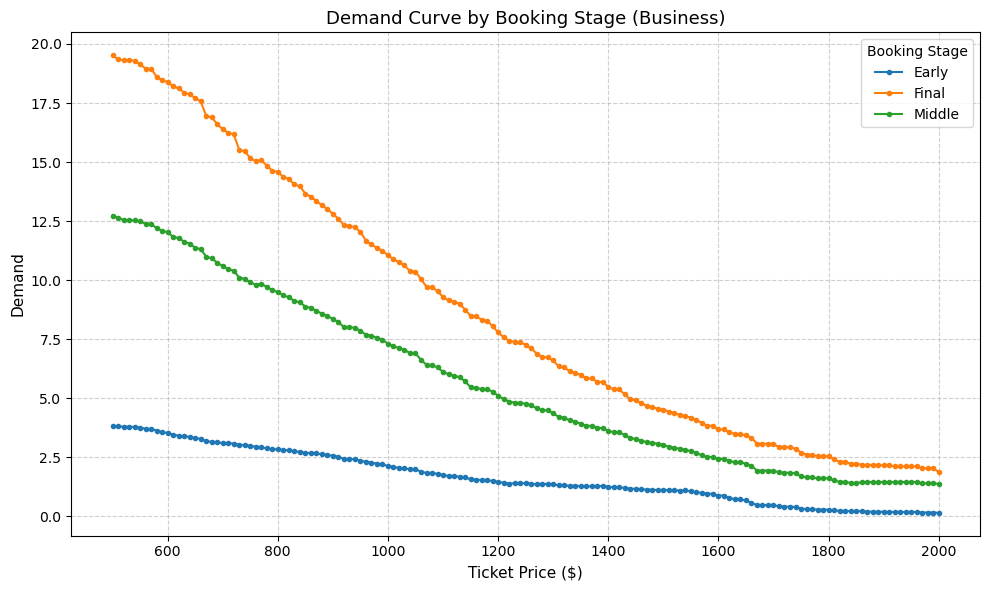

In [26]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load saved artifacts
preprocessor = joblib.load("preprocessor_pipeline_demand_business.joblib")
model = joblib.load("demand_forecasting_business_model.joblib")

# 2. Define price range
prices = np.arange(500, 2010, 10)  

# 3. Generate predictions across the price spectrum
results = []

# Iterate directly through 'df' since each row already represents a unique booking stage
for _, flight in df.iterrows():
    stage = flight["booking_stage"]

    # Replicate the single flight row for each price point
    scenario_df = pd.DataFrame([flight] * len(prices))

    # Overwrite the price feature with the scenario prices
    scenario_df["price"] = prices

    # Preprocess features and predict demand
    X_transformed = preprocessor.transform(scenario_df)
    demand = model.predict(X_transformed)

    # Store scenario results
    stage_results = pd.DataFrame(
        {
            "booking_stage": stage,
            "price": prices,
            "demand": demand,  
        }
    )
    results.append(stage_results)

# Combine all predictions into a single DataFrame
demand_df = pd.concat(results, ignore_index=True)

# 4. Plot Demand Curves
plt.figure(figsize=(10, 6))
for stage, group in demand_df.groupby("booking_stage"):
    plt.plot(
        group["price"],
        group["demand"],
        label=stage,
        marker="o",
        markersize=3,
    )

plt.title("Demand Curve by Booking Stage (Business)", fontsize=13)
plt.xlabel("Ticket Price ($)", fontsize=11)
plt.ylabel("Demand", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Booking Stage")
plt.tight_layout()
plt.show()

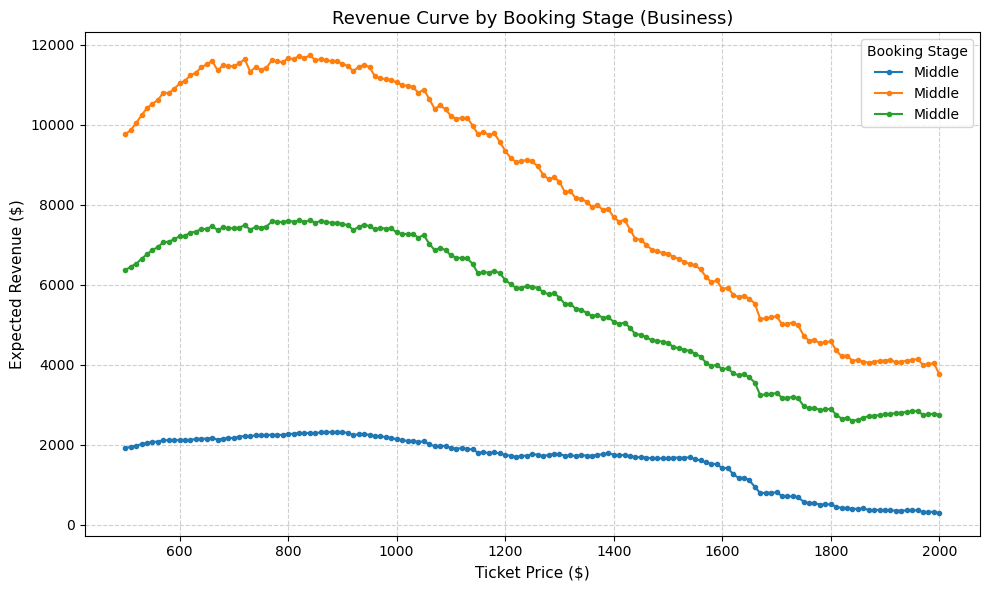

--- Revenue-Maximizing Price Points ---
booking_stage  price  expected_revenue
        Early    870       2314.118116
        Final    840      11738.438706
       Middle    840       7610.311521


In [27]:
# 1. Compute expected revenue
demand_df["expected_revenue"] = (
    demand_df["price"] * demand_df["demand"]
)

# 2. Plot Revenue Curves
plt.figure(figsize=(10, 6))
for dest, group in demand_df.groupby("booking_stage"):
    plt.plot(
        group["price"],
        group["expected_revenue"],
        label=stage,
        marker="o",
        markersize=3,
    )

plt.title("Revenue Curve by Booking Stage (Business)", fontsize=13)
plt.xlabel("Ticket Price ($)", fontsize=11)
plt.ylabel("Expected Revenue ($)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Booking Stage")
plt.tight_layout()
plt.show()

# 3. Print the optimal revenue-maximizing price for each booking stage
optimal_prices = demand_df.loc[
    demand_df.groupby("booking_stage")["expected_revenue"].idxmax()
]

print("--- Revenue-Maximizing Price Points ---")
print(
    optimal_prices[["booking_stage", "price", "expected_revenue"]].to_string(
        index=False
    )
)

In [28]:
import numpy as np
import pandas as pd

# Ensure demand_df is sorted by Booking Stage and price
demand_df = demand_df.sort_values(by=["booking_stage", "price"]).copy()

# List to store elasticity values
elasticity_results = []

# Group by booking stage to calculate step-by-step elasticity
for stage, group in demand_df.groupby("booking_stage"):
    group = group.reset_index(drop=True)

    # Shift values to calculate delta (dq and dp)
    p1 = group["price"].iloc[:-1].values
    p2 = group["price"].iloc[1:].values

    q1 = group["demand"].iloc[:-1].values
    q2 = group["demand"].iloc[1:].values

    dp = p2 - p1
    dq = q2 - q1

    # Avoid division by zero if initial demand is 0
    valid_mask = q1 != 0
    dq, dp, p1, q1 = (
        dq[valid_mask],
        dp[valid_mask],
        p1[valid_mask],
        q1[valid_mask],
    )

    # Point elasticity formula: (dq / dp) * (p1 / q1)
    elasticities = (dq / dp) * (p1 / q1)

    # Average elasticity for this route
    avg_elasticity = np.mean(elasticities)

    elasticity_results.append(
        {"booking_stage": stage, "avg_elasticity": avg_elasticity}
    )

# Create summary DataFrame for route elasticity
elasticity_df = pd.DataFrame(elasticity_results)
print(elasticity_df)

  booking_stage  avg_elasticity
0         Early       -3.030061
1         Final       -2.016697
2        Middle       -1.871463


In [29]:
# 1. Select and rename required columns from demand_df
full_price_table = demand_df[
    ["booking_stage", "price", "demand", "expected_revenue"]
].copy()

# 2. Rename columns to match requested headers
full_price_table = full_price_table.rename(
    columns={
        "booking_stage": "Booking Stage",
        "price": "Price",
        "demand": "Demand",
        "expected_revenue": "Expected Revenue",
    }
)

# 3. Sort cleanly by Booking Stage and Price
full_price_table = full_price_table.sort_values(
    by=["Booking Stage", "Price"]
).reset_index(drop=True)

# 4. Save the full table to CSV (with unformatted numbers for data precision)
full_price_table.to_csv(
    "Expected_Revenue_Business_JFK.csv", index=False
)
print(
    "Table successfully saved to 'Expected_Revenue_Business_JFK.csv'"
)

# 5. Format numbers for clean display
formatted_table = full_price_table.copy()
formatted_table["Price"] = formatted_table["Price"].apply(
    lambda x: f"${x:,.0f}"
)
formatted_table["Demand"] = formatted_table["Demand"].round(1)
formatted_table["Expected Revenue"] = formatted_table["Expected Revenue"].apply(
    lambda x: f"${x:,.2f}"
)

# 6. Display only the first 15 rows
print("\n--- First 25 Rows ---")
print(formatted_table.head(25).to_string(index=False))

Table successfully saved to 'Expected_Revenue_Business_JFK.csv'

--- First 25 Rows ---
Booking Stage Price  Demand Expected Revenue
        Early  $500     3.8        $1,914.33
        Early  $510     3.8        $1,941.04
        Early  $520     3.8        $1,973.10
        Early  $530     3.8        $2,011.04
        Early  $540     3.8        $2,040.84
        Early  $550     3.8        $2,067.64
        Early  $560     3.7        $2,073.26
        Early  $570     3.7        $2,110.28
        Early  $580     3.6        $2,104.69
        Early  $590     3.6        $2,103.53
        Early  $600     3.5        $2,116.98
        Early  $610     3.5        $2,106.55
        Early  $620     3.4        $2,118.49
        Early  $630     3.4        $2,138.44
        Early  $640     3.4        $2,151.00
        Early  $650     3.3        $2,145.99
        Early  $660     3.3        $2,169.36
        Early  $670     3.2        $2,123.35
        Early  $680     3.2        $2,149.00
        Early